# Entregable 4: Preparacion de Datos para Dashboard Power BI
## Indicadores Economicos Regionales (2020-2024)

Se realiza el analisis exploratorio de los datos que alimentan el dashboard.

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print('Librerias cargadas')

/home/mrdavidalv/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Librerias cargadas


## 1. Carga y exploracion

In [2]:
df = pd.read_csv('4 Indicadores_Economicos_Regionales.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Trimestre'] = df['Fecha'].dt.quarter

print(f'Registros: {len(df)}')
print(f'Regiones: {list(df["Región"].unique())}')
print(f'Sectores: {list(df["Sector"].unique())}')
print(f'Periodo: {df["Año"].min()} - {df["Año"].max()}')
df.head()

Registros: 2000
Regiones: ['Sur', 'Norte', 'Occidente', 'Oriente', 'Centro']
Sectores: ['Agricultura', 'Servicios', 'Industria']
Periodo: 2020 - 2024


,Fecha,Región,PIB,Tasa_Desempleo,Inflación,Comercio_Exterior,Producción_Industrial,Sector,Año,Mes,Trimestre
0,2020-01-01,Sur,5496.71,12.05,2.59,186.17,96.49,Agricultura,2020,1,1
1,2021-03-01,Norte,4765.86,4.64,4.20,357.92,111.51,Servicios,2021,3,1
2,2024-02-01,Occidente,4530.53,6.00,0.10,254.26,103.63,Industria,2024,2,1
3,2020-01-01,Norte,3086.72,8.75,0.75,98.72,104.71,Agricultura,2020,1,1
4,2021-09-01,Occidente,4091.98,9.02,3.71,58.77,101.01,Agricultura,2021,9,3


In [3]:
df.describe().round(2)

,Fecha,PIB,Tasa_Desempleo,Inflación,Comercio_Exterior,Producción_Industrial,Año,Mes,Trimestre
count,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,2022-07-03 05:41:59.999999744,5006.36,9.52,1.98,197.39,100.03,2022.03,6.67,2.54
min,2020-01-01 00:00:00,1163.34,4.00,-1.00,-101.95,55.89,2020.00,1.00,1.00
25%,2021-03-01 00:00:00,4315.96,6.76,0.49,128.98,90.16,2021.00,4.00,2.00
50%,2022-07-01 00:00:00,5020.45,9.52,1.96,197.64,99.83,2022.00,7.00,3.00
75%,2023-11-01 00:00:00,5708.48,12.30,3.45,265.48,109.98,2023.00,10.00,4.00
max,2024-12-01 00:00:00,8852.73,14.99,4.99,519.31,150.66,2024.00,12.00,4.00
std,NaN,1021.97,3.17,1.71,100.38,14.90,1.44,3.42,1.11


## 2. Indicadores por region

In [4]:
por_region = df.groupby('Región').agg({
    'PIB': 'mean',
    'Tasa_Desempleo': 'mean',
    'Inflación': 'mean',
    'Comercio_Exterior': 'mean',
    'Producción_Industrial': 'mean'
}).round(2)
print('Indicadores promedio por region:')
por_region

Indicadores promedio por region:


,PIB,Tasa_Desempleo,Inflación,Comercio_Exterior,Producción_Industrial
Región,,,,,
Centro,5153.00,9.49,1.86,195.39,99.83
Norte,4946.20,9.66,2.08,193.64,99.70
Occidente,4987.50,9.53,1.99,201.88,100.61
Oriente,4955.91,9.45,1.88,196.44,100.45
Sur,4990.13,9.50,2.06,199.09,99.50


## 3. Indicadores por sector

In [5]:
por_sector = df.groupby('Sector').agg({
    'PIB': 'mean',
    'Tasa_Desempleo': 'mean'
}).round(2)
print('Indicadores por sector:')
por_sector

Indicadores por sector:


,PIB,Tasa_Desempleo
Sector,,
Agricultura,5042.82,9.63
Industria,4958.88,9.53
Servicios,5017.66,9.41


## 4. Tendencia temporal

In [6]:
por_anio = df.groupby('Año').agg({
    'PIB': 'mean',
    'Tasa_Desempleo': 'mean',
    'Inflación': 'mean'
}).round(2)
print('Tendencia anual:')
por_anio

Tendencia anual:


,PIB,Tasa_Desempleo,Inflación
Año,,,
2020,4938.86,9.75,2.00
2021,5035.90,9.39,2.01
2022,4997.83,9.41,1.94
2023,5083.60,9.52,1.92
2024,4980.28,9.53,2.01


## 5. Visualizaciones

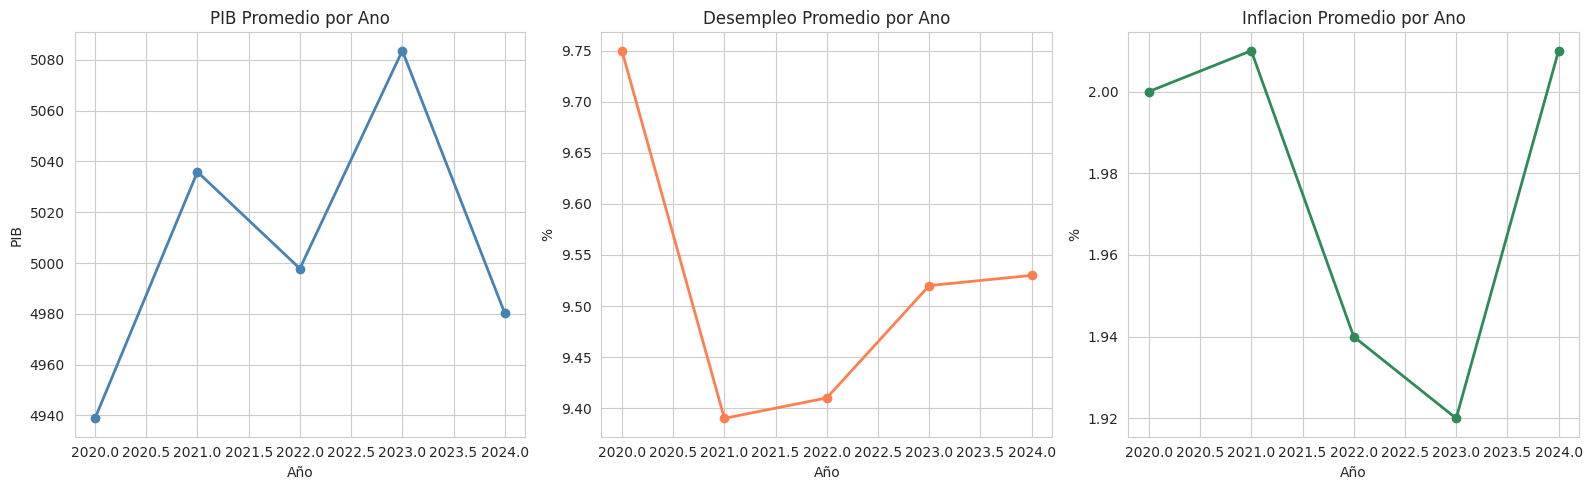

Graficos guardados


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

por_anio['PIB'].plot(marker='o', ax=axes[0], color='steelblue', linewidth=2)
axes[0].set_title('PIB Promedio por Ano')
axes[0].set_ylabel('PIB')

por_anio['Tasa_Desempleo'].plot(marker='o', ax=axes[1], color='coral', linewidth=2)
axes[1].set_title('Desempleo Promedio por Ano')
axes[1].set_ylabel('%')

por_anio['Inflación'].plot(marker='o', ax=axes[2], color='seagreen', linewidth=2)
axes[2].set_title('Inflacion Promedio por Ano')
axes[2].set_ylabel('%')

plt.tight_layout()
plt.savefig('tendencias_anuales.png', dpi=150)
plt.show()
print('Graficos guardados')

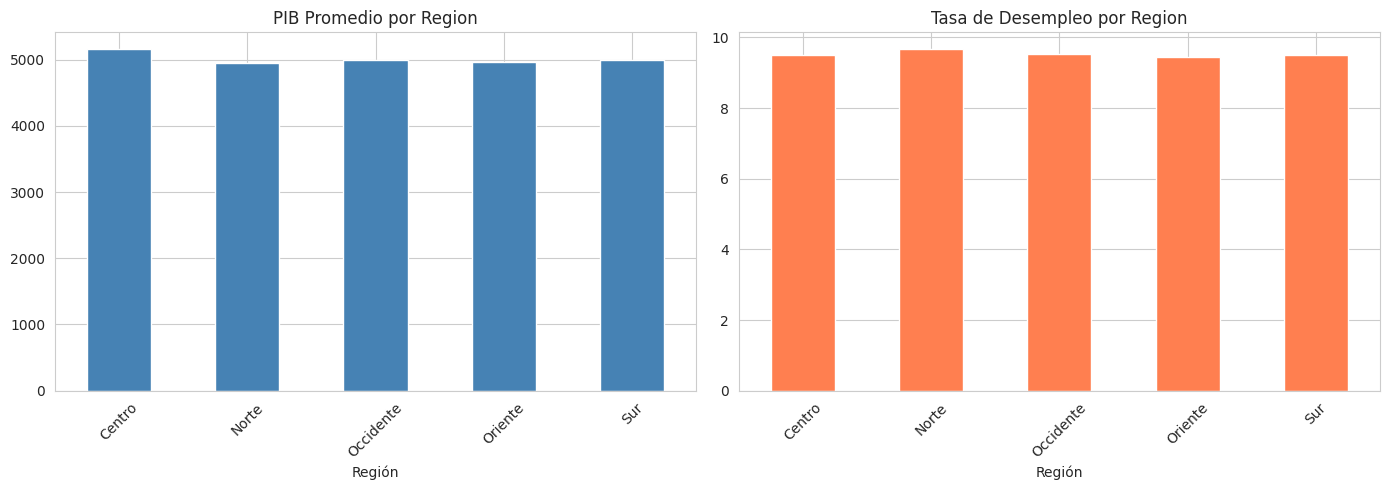

Graficos guardados


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

por_region['PIB'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('PIB Promedio por Region')
axes[0].tick_params(axis='x', rotation=45)

por_region['Tasa_Desempleo'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Tasa de Desempleo por Region')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('comparacion_regional.png', dpi=150)
plt.show()
print('Graficos guardados')

## Notas para Power BI

Con estos datos explorados, el dashboard en Power BI incluye:
- Tarjetas KPI para indicadores principales
- Graficos de lineas para tendencias temporales
- Barras agrupadas para comparacion entre regiones
- Segmentadores por Region, Sector, Ano y Trimestre